In [145]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pca import pca
from sklearn import datasets
from sklearn.decomposition import PCA

In [146]:
# from GitHub
username = "datagus"
repository = "ASDA2025"
directory = "datasets/homework_week10/happy.csv"

github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"

# read CSV (note: separator is ;)
happy_df = pd.read_csv(github_url)

# convert quality to string
#wine_df["quality"] = wine_df["quality"].astype(str)

#wine_df=wine_df.loc[wine_df['quality'].isin(['5','6','7'])]

happy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [147]:
# shape of the dataframe
print("Shape of the dataframe:", happy_df.shape)

Shape of the dataframe: (156, 9)


In [163]:
#from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/income.xlsx"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
income_xls = pd.ExcelFile(github_url)
income_df = pd.read_excel(income_xls, 'List of economies')

In [164]:
happy_df['Country or region'] = happy_df['Country or region'].str.strip()
income_df['Economy'] = income_df['Economy'].str.strip()


In [165]:
happy_df = happy_df.merge(
    income_df,
    left_on='Country or region',
    right_on='Economy',
    how='left'
)


In [166]:
features = ['GDP per capita', 'Social support', 'Healthy life expectancy',
            'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

X = happy_df[features]


[19-12-2025 14:12:54] [pca.pca] [INFO] PCA reduction performed to capture at least 95.0% explained variance using 6 columns of the input data.
[19-12-2025 14:12:54] [pca.pca] [INFO] Fit using PCA.
[19-12-2025 14:12:54] [pca.pca] [INFO] Compute loadings and PCs.
[19-12-2025 14:12:54] [pca.pca] [INFO] Compute explained variance.
[19-12-2025 14:12:54] [pca.pca] [INFO] The top 5 principal component(s) explains >= 95.00% of the explained variance.
[19-12-2025 14:12:54] [pca.pca] [INFO] The PCA reduction is performed on 6 variables (columns) of the input dataframe.
[19-12-2025 14:12:54] [pca.pca] [INFO] Fit using PCA.
[19-12-2025 14:12:54] [pca.pca] [INFO] Compute loadings and PCs.
[19-12-2025 14:12:54] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[5]
[19-12-2025 14:12:54] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[19-12-2025 14:12:54] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[19

(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': 'The top 5 Principal Component(s) explains [97.43%] of the variance.'}, xlabel='PC1 (48.8% expl.var)', ylabel='PC2 (23.2% expl.var)'>)

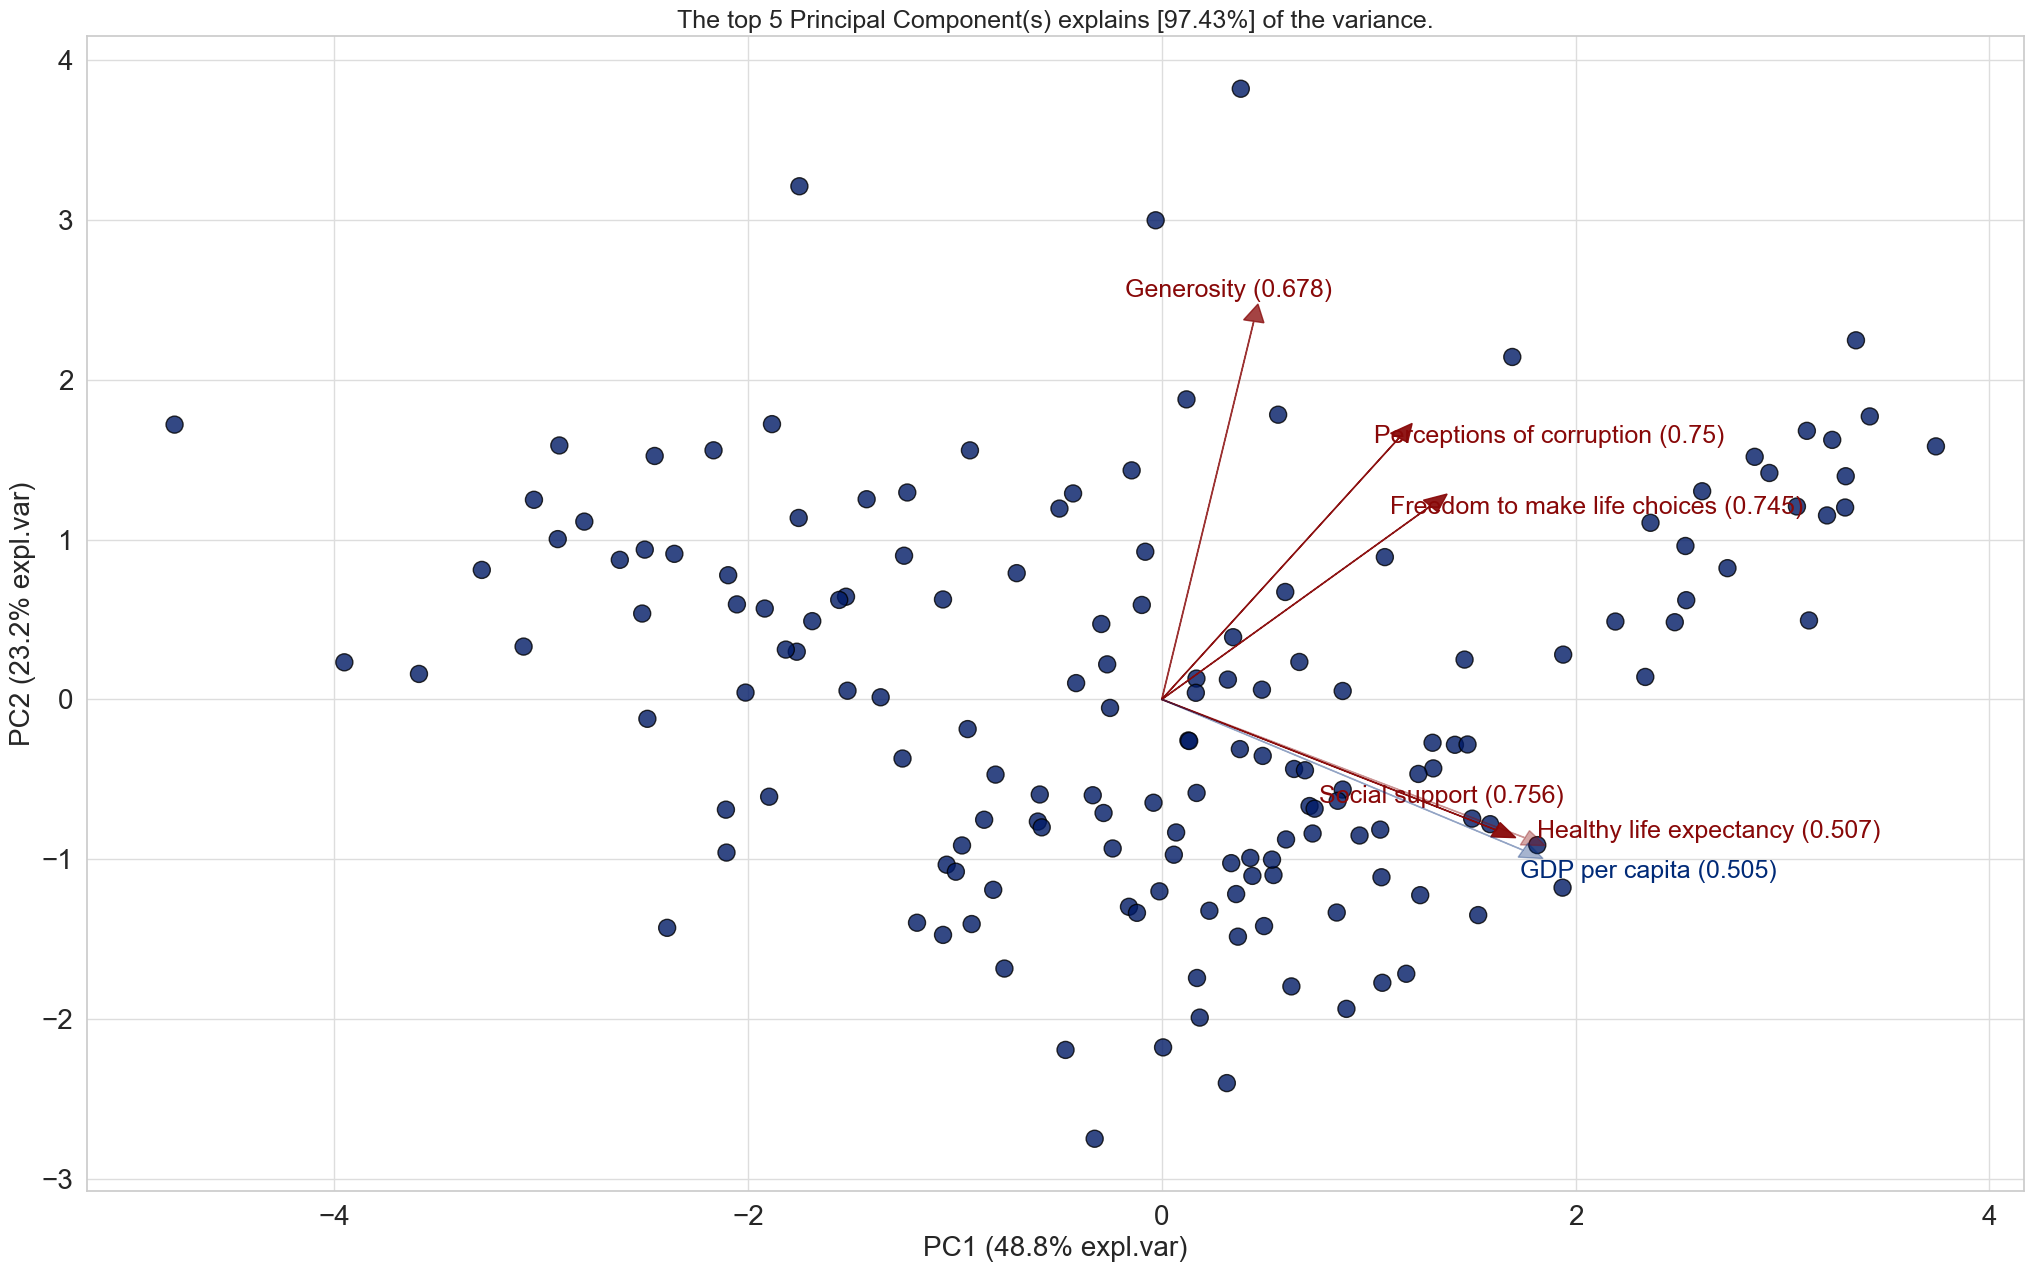

In [167]:
df = happy_df.copy()
y = df['Country or region'] 
X = happy_df[features]

# Scale the data
X_scaled = StandardScaler().fit_transform(X)
labels = X.columns


# PCA
model = pca()
#results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

# Scatter plot with loadings
model.biplot()


In [168]:
df = happy_df.copy()
y = df['Region'] 
X = happy_df[features]

# Scale the data
X_scaled = StandardScaler().fit_transform(X)
labels = X.columns


# PCA
model = pca()
#results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

results = model.fit_transform(X_scaled, col_labels=labels, row_labels=y)

# Scatter plot with loadings
model.biplot()



KeyError: 'Region'

## Loadings

In [ ]:
model.results['topfeat']

,PC,feature,loading,type
0,PC1,Healthy life expectancy,0.507478,best
1,PC2,Generosity,0.677582,best
2,PC3,Freedom to make life choices,0.744680,best
3,PC4,Perceptions of corruption,0.749989,best
4,PC5,Social support,0.756395,best
5,PC1,GDP per capita,0.504522,weak


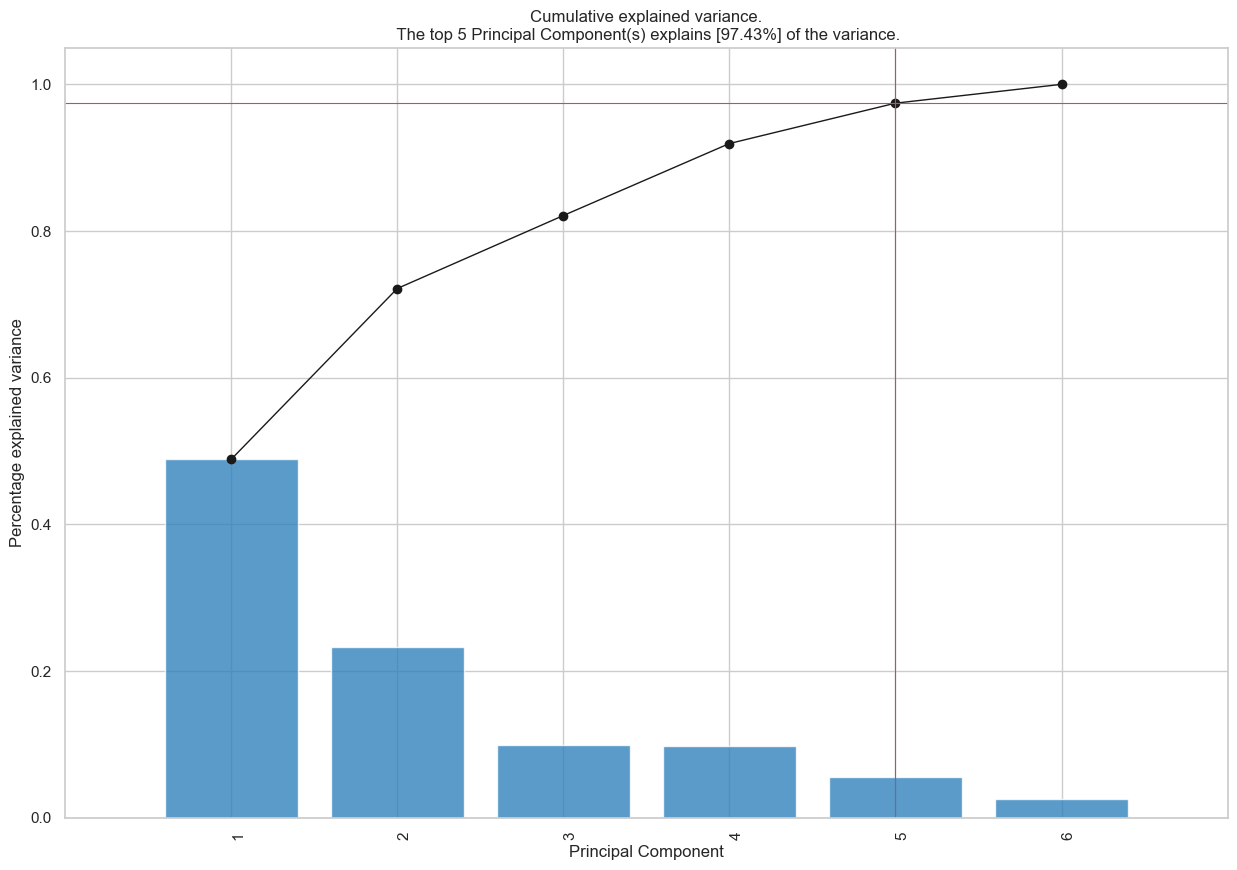

In [ ]:
model.plot();

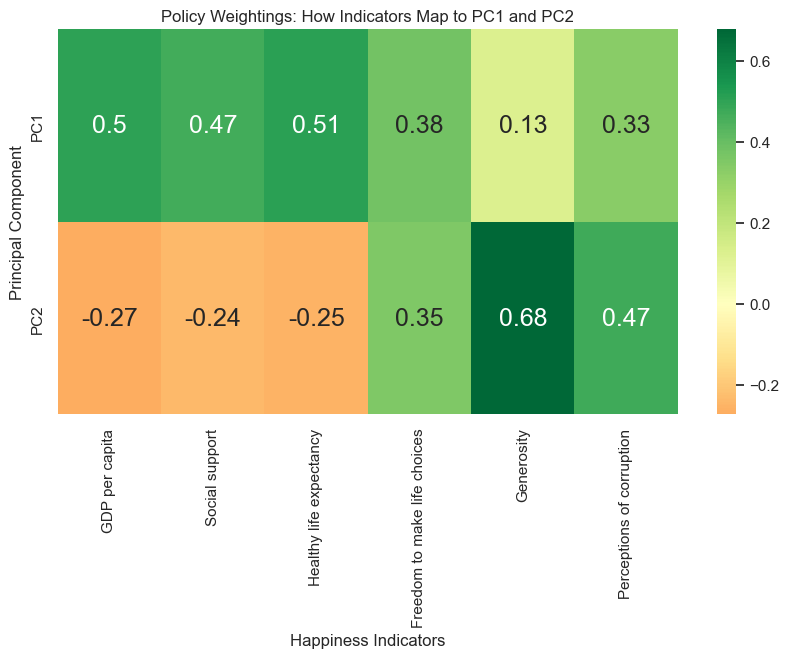

In [ ]:
# Extract Loadings for PC1 and PC2
loadings = model.results['loadings'].iloc[0:2, :] 

# Plotting the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(loadings, annot=True, cmap='RdYlGn', center=0)
plt.title('Policy Weightings: How Indicators Map to PC1 and PC2')
plt.ylabel('Principal Component')
plt.xlabel('Happiness Indicators')
plt.show()

In [ ]:
# Get the coordinates of all countries in the PCA space
pca_coords = model.results['PC']
pca_coords.index = happy_df['Country or region']

# Identify extremes for PC1 (The Development Foundation)
top_pc1 = pca_coords['PC1'].nlargest(5)
bottom_pc1 = pca_coords['PC1'].nsmallest(5)

# Identify extremes for PC2 (Institutional & Social Quality)
top_pc2 = pca_coords['PC2'].nlargest(5)
bottom_pc2 = pca_coords['PC2'].nsmallest(5)



In [ ]:
# Extract the PC DataFrame from results dict
pc_scores = results['PC']  # This is a DataFrame

# Keep only PC1 and PC2
pca_df = pc_scores.iloc[:, :2].copy()

# Reset index to make country names a column
pca_df = pca_df.reset_index()  # The index becomes a column named 'index'
pca_df.rename(columns={'index':'Country or region'}, inplace=True)

# Merge with the main df
df = df.merge(pca_df, on='Country or region', how='left')

# Check
df[['Country or region','PC1','PC2','Score']].head()


,Country or region,PC1,PC2,Score
0,Finland,3.214870,1.151421,7.632
1,Norway,3.305339,1.396784,7.594
2,Denmark,3.421553,1.771251,7.555
3,Iceland,2.733791,0.821269,7.495
4,Switzerland,3.302394,1.200969,7.487


In [ ]:
# Check
df[['Country or region','PC1','PC2','Score']].tail()

,Country or region,PC1,PC2,Score
151,Yemen,-2.106542,-0.690422,3.355
152,Tanzania,-1.230050,1.294995,3.303
153,South Sudan,-3.286320,0.810360,3.254
154,Central African Republic,-4.771123,1.719800,3.083
155,Burundi,-3.950630,0.232015,2.905


In [ ]:
# Top 5 PC1 countries including Happiness Score
top_pc1 = df.nlargest(5, 'PC1')[['Country or region', 'PC1', 'Score']]

# Top 5 PC2 countries including Happiness Score
top_pc2 = df.nlargest(5, 'PC2')[['Country or region', 'PC2', 'Score']]

# Print results
print("--- PC1: High Socio-Economic Foundations ---")
print(top_pc1.to_string(index=False))

print("\n--- PC2: High Social/Institutional Quality ---")
print(top_pc2.to_string(index=False))

--- PC1: High Socio-Economic Foundations ---
Country or region      PC1  Score
        Singapore 3.741241  6.343
          Denmark 3.421553  7.555
      New Zealand 3.354731  7.324
           Norway 3.305339  7.594
      Switzerland 3.302394  7.487

--- PC2: High Social/Institutional Quality ---
Country or region      PC2  Score
          Myanmar 3.822219  4.308
          Somalia 3.211842  4.982
           Rwanda 2.998874  3.408
      New Zealand 2.247588  7.324
       Uzbekistan 2.143325  6.096


In [ ]:
low_pc1 = df.nsmallest(5, 'PC1')[['Country or region', 'PC1', 'Score']]
low_pc2 = df.nsmallest(5, 'PC2')[['Country or region', 'PC2', 'Score']]
# Print results
print("--- PC1: Low Socio-Economic Foundations ---")
print(low_pc1.to_string(index=False))

print("\n--- PC2: Low Social/Institutional Quality ---")
print(low_pc2.to_string(index=False))


--- PC1: Low Socio-Economic Foundations ---
       Country or region       PC1  Score
Central African Republic -4.771123  3.083
                 Burundi -3.950630  2.905
             Afghanistan -3.589953  3.632
             South Sudan -3.286320  3.254
                    Chad -3.084364  4.301

--- PC2: Low Social/Institutional Quality ---
Country or region       PC2  Score
           Greece -2.750263  5.358
        Lithuania -2.401985  5.952
        Venezuela -2.194198  4.806
          Hungary -2.178391  5.620
         Bulgaria -1.991985  4.933
